<a href="https://colab.research.google.com/github/lidimoura/challenge3-data-science-TelecomX2/blob/main/Challenge3_dataScience_TelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X2: Prevendo Churn (Machine Learning)

## 1. Preparação e Limpeza de Dados
Nesta etapa, estamos carregando os dados tratados na fase anterior, removendo colunas identificadoras e redundantes, e transformando variáveis categóricas em numéricas (One-Hot Encoding) para que o modelo possa processá-las.

In [13]:
import pandas as pd

# Carregando os dados tratados do Desafio 1
df_ml = pd.read_csv('dados_tratados.csv')

# Removendo colunas que não agregam valor preditivo ou são redundantes
colunas_fora = ['id_cliente', 'customerID', 'gasto_diario']
df_ml = df_ml.drop(columns=[c for c in colunas_fora if c in df_ml.columns])

# Preparando a variável alvo (Transformando 'Sim'/'Não' em 1/0)
if df_ml['Churn'].dtype == 'object':
    df_ml['Churn'] = df_ml['Churn'].replace({'Sim': 1, 'Não': 0})

# Realizando o One-Hot Encoding (Transformando textos em colunas de 0 e 1)
df_final = pd.get_dummies(df_ml).astype(int)

# Visualizando o resultado da transformação
display(df_final.head())

/tmp/ipykernel_3890/5578354.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Churn,meses_contrato,gasto_mensal,gasto_total,genero_Feminino,genero_Masculino,idoso_Não,idoso_Sim,possui_parceiro_Não,possui_parceiro_Sim,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensal,fatura_digital_Não,fatura_digital_Sim,metodo_pagamento_Cartão de crédito,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária
0,0,9,65,593,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1,0,9,59,542,0,1,1,0,1,0,...,1,0,0,1,1,0,0,0,1,0
2,1,4,73,280,0,1,1,0,1,0,...,0,0,0,1,0,1,0,1,0,0
3,1,13,98,1237,0,1,0,1,0,1,...,1,0,0,1,0,1,0,1,0,0
4,1,3,83,267,1,0,0,1,0,1,...,0,0,0,1,0,1,0,0,1,0


## 2. Análise de equilíbrio de classes
Avaliando a proporção de clientes que evadiram (Churn = 1) em relação aos que permaneceram (Churn = 0) para identificar possíveis desbalanceamentos que possam enviesar os modelos preditivos.

In [14]:
import plotly.express as px

# Calculando a proporção da variável alvo
proporcao = df_final['Churn'].value_counts(normalize=True) * 100
print(f"Proporção da Classe Alvo (Churn):\n{proporcao}\n")

# Criando o gráfico para visualizar o desbalanceamento
fig_balanco = px.pie(df_final,
                     names='Churn',
                     title='Proporção de Clientes: Ficaram (0) vs Saíram (1)',
                     color_discrete_sequence=['#1f77b4', '#d62728'])
fig_balanco.show()

Proporção da Classe Alvo (Churn):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64



## 3. Correlação e seleção de variáveis
Analisando a matriz de correlação para identificar quais variáveis numéricas possuem maior força de atração (positiva ou negativa) com o cancelamento (Churn).

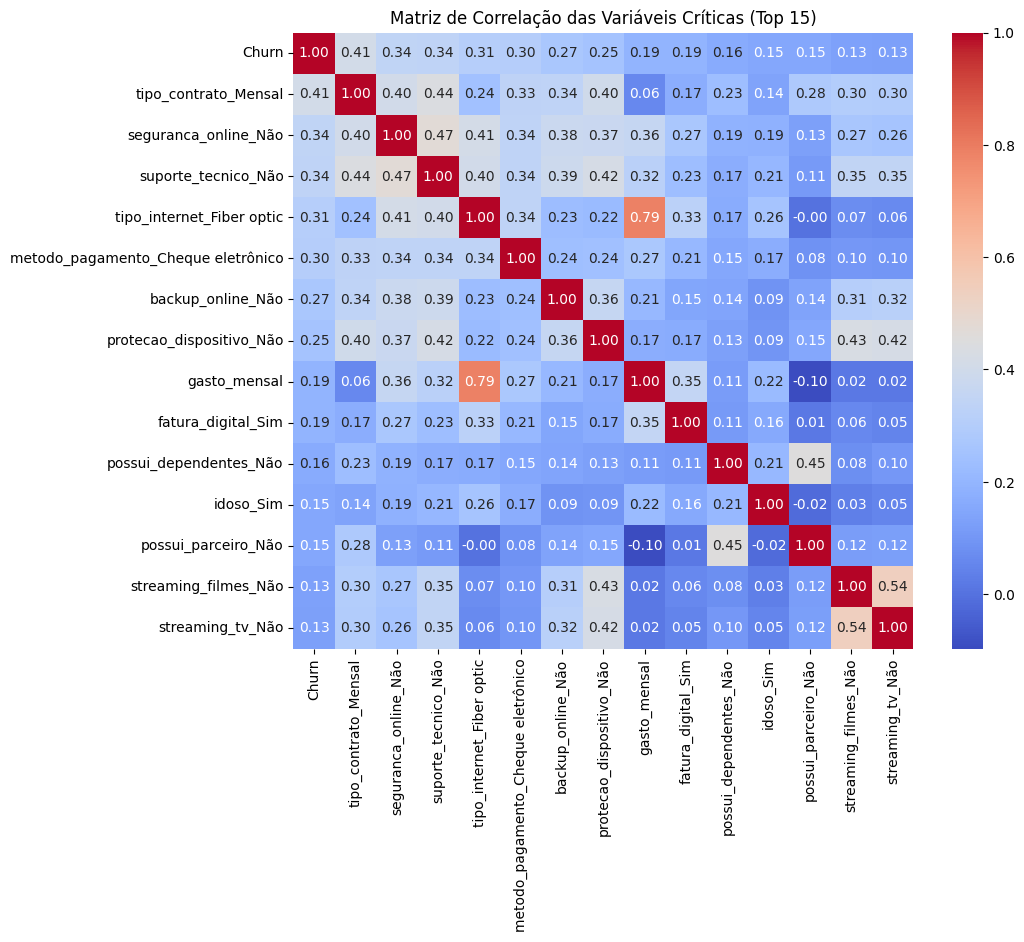

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação de todas as variáveis em relação ao Churn
correlacao = df_final.corr()['Churn'].sort_values(ascending=False)

# Selecionando apenas as 15 características mais influentes para o gráfico não ficar poluído
top_variaveis = correlacao.index[:15]

# Criando o Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[top_variaveis].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Críticas (Top 15)')
plt.show()


## 4. Divisão dos dados e balanceamento de classes (smote)

Para garantir que o nosso modelo aprenda os padrões corretamente sem "decorar" os dados, primeiro dividimos a base em treino (70%) e teste (30%). Em seguida, aplicamos o smote apenas nos dados de treino para equilibrar a quantidade de clientes que saíram e ficaram, melhorando a capacidade de previsão do algoritmo.

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# separando características (X) e a variável alvo (y)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# dividindo os dados (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# aplicando o smote apenas nos dados de treino para evitar vazamento de dados
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"distribuição antes do smote (treino): \n{y_train.value_counts()}\n")
print(f"distribuição depois do smote (treino): \n{y_train_bal.value_counts()}")

distribuição antes do smote (treino): 
Churn
0    3622
1    1308
Name: count, dtype: int64

distribuição depois do smote (treino): 
Churn
0    3622
1    3622
Name: count, dtype: int64


## 5. Normalização dos dados

Modelos baseados em distância (como regressão logística e knn) exigem que todas as variáveis estejam na mesma escala. Aqui usamos o `MinMaxScaler` para colocar todos os valores numéricos entre 0 e 1, evitando que variáveis com valores altos (como o gasto total) dominem o modelo.

In [18]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# instanciando o normalizador
scaler = MinMaxScaler()

# ajustando o normalizador com os dados de treino e já transformando
X_train_norm = scaler.fit_transform(X_train_bal)

# transformando os dados de teste (usando o padrão aprendido no treino)
X_test_norm = scaler.transform(X_test)

# convertendo de volta para dataframe apenas para facilitar a visualização
X_train_norm_df = pd.DataFrame(X_train_norm, columns=X.columns)
display(X_train_norm_df.head())

,meses_contrato,gasto_mensal,gasto_total,genero_Feminino,genero_Masculino,idoso_Não,idoso_Sim,possui_parceiro_Não,possui_parceiro_Sim,possui_dependentes_Não,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensal,fatura_digital_Não,fatura_digital_Sim,metodo_pagamento_Cartão de crédito,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária
0,0.194444,0.58,0.128627,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.069444,0.52,0.039959,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.486111,0.57,0.296637,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.805556,0.68,0.563105,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.027778,0.31,0.013128,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
